# 08 — Regression Analysis
**References:** Galton (1886) · Gauss (1809) · Pearson (1895) · Anscombe (1973)

## Narrative thread
```
Correlation -> Simple linear regression -> Multiple regression -> Diagnostics -> Regularization
```

## Correlation

**Pearson correlation:** $r = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$ — measures *linear* association.
Range $[-1, 1]$; $r^2 = R^2$ in simple regression.

**Spearman correlation:** Pearson $r$ applied to ranks — measures *monotonic* association.
Robust to outliers and non-normality.

**Anscombe's quartet (1973):** four datasets with identical $\bar{x}, \bar{y}, r, \hat{\beta}$
but completely different patterns. Always plot your data.

## Simple linear regression

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i \qquad \varepsilon_i \sim N(0,\sigma^2)$$

OLS estimators:
$$\hat{\beta}_1 = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2} = \frac{\text{Cov}(x,y)}{\text{Var}(x)} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

Geometric interpretation: $\hat{\beta}_1 = r_{xy} \cdot (s_y / s_x)$ — the slope equals
the correlation times the ratio of standard deviations.

## Regression to the mean

Galton (1886): tall parents have children who are tall, but *less* tall than the parents.
This is not genetics — it is a pure statistical artifact whenever $|r| < 1$.

If $X$ and $Y$ are standardized: $\hat{Y} = r \cdot X$, so predicted $Y$ is always
closer to the mean than $X$ (since $|r| < 1$). Always occurs with imperfect correlation.

## Multiple regression

$$\mathbf{y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon} \qquad \hat{\boldsymbol{\beta}} = (X^\top X)^{-1}X^\top \mathbf{y}$$

**Adjusted $R^2$:** $\bar{R}^2 = 1 - (1-R^2)\frac{n-1}{n-k-1}$ — penalizes for extra predictors.

## Diagnostics: the four residual plots

| Plot | What to check |
|---|---|
| Residuals vs Fitted | Linearity (should be flat) |
| Q-Q of residuals | Normality (should be on the line) |
| Scale-Location | Homoskedasticity (spread should be constant) |
| Residuals vs Leverage | Influential points (Cook's distance) |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

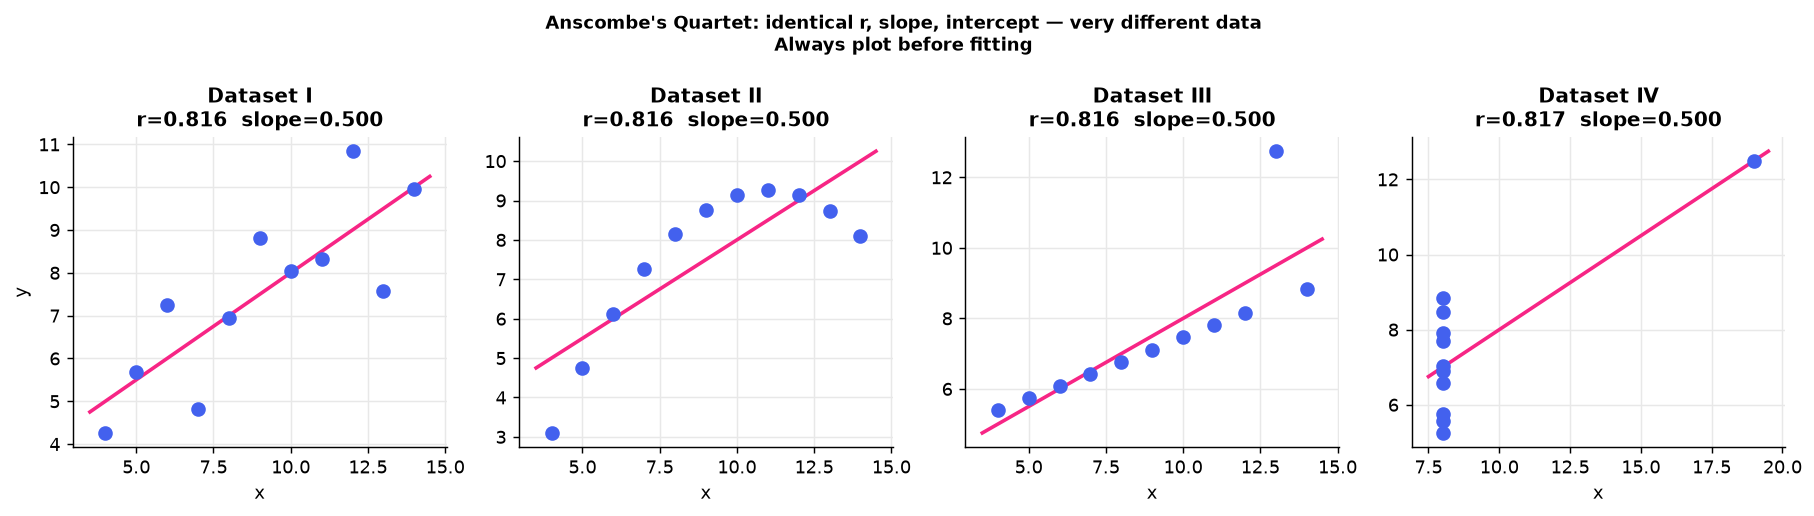

In [2]:
# ── Anscombe's quartet ───────────────────────────────────────────────────
anscombe = {
    'I':   ([10,8,13,9,11,14,6,4,12,7,5], [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]),
    'II':  ([10,8,13,9,11,14,6,4,12,7,5], [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]),
    'III': ([10,8,13,9,11,14,6,4,12,7,5], [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]),
    'IV':  ([8,8,8,8,8,8,8,19,8,8,8],     [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, (x, y)) in zip(axes, anscombe.items()):
    x, y = np.array(x), np.array(y)
    m, b, r, p, se = stats.linregress(x, y)
    ax.scatter(x, y, color='#4361ee', s=50, zorder=3)
    xline = np.linspace(x.min()-0.5, x.max()+0.5, 100)
    ax.plot(xline, m*xline+b, color='#f72585', lw=2)
    ax.set_title(f'Dataset {name}\nr={r:.3f}  slope={m:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y') if name=='I' else None
plt.suptitle("Anscombe's Quartet: identical r, slope, intercept — very different data\nAlways plot before fitting",
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

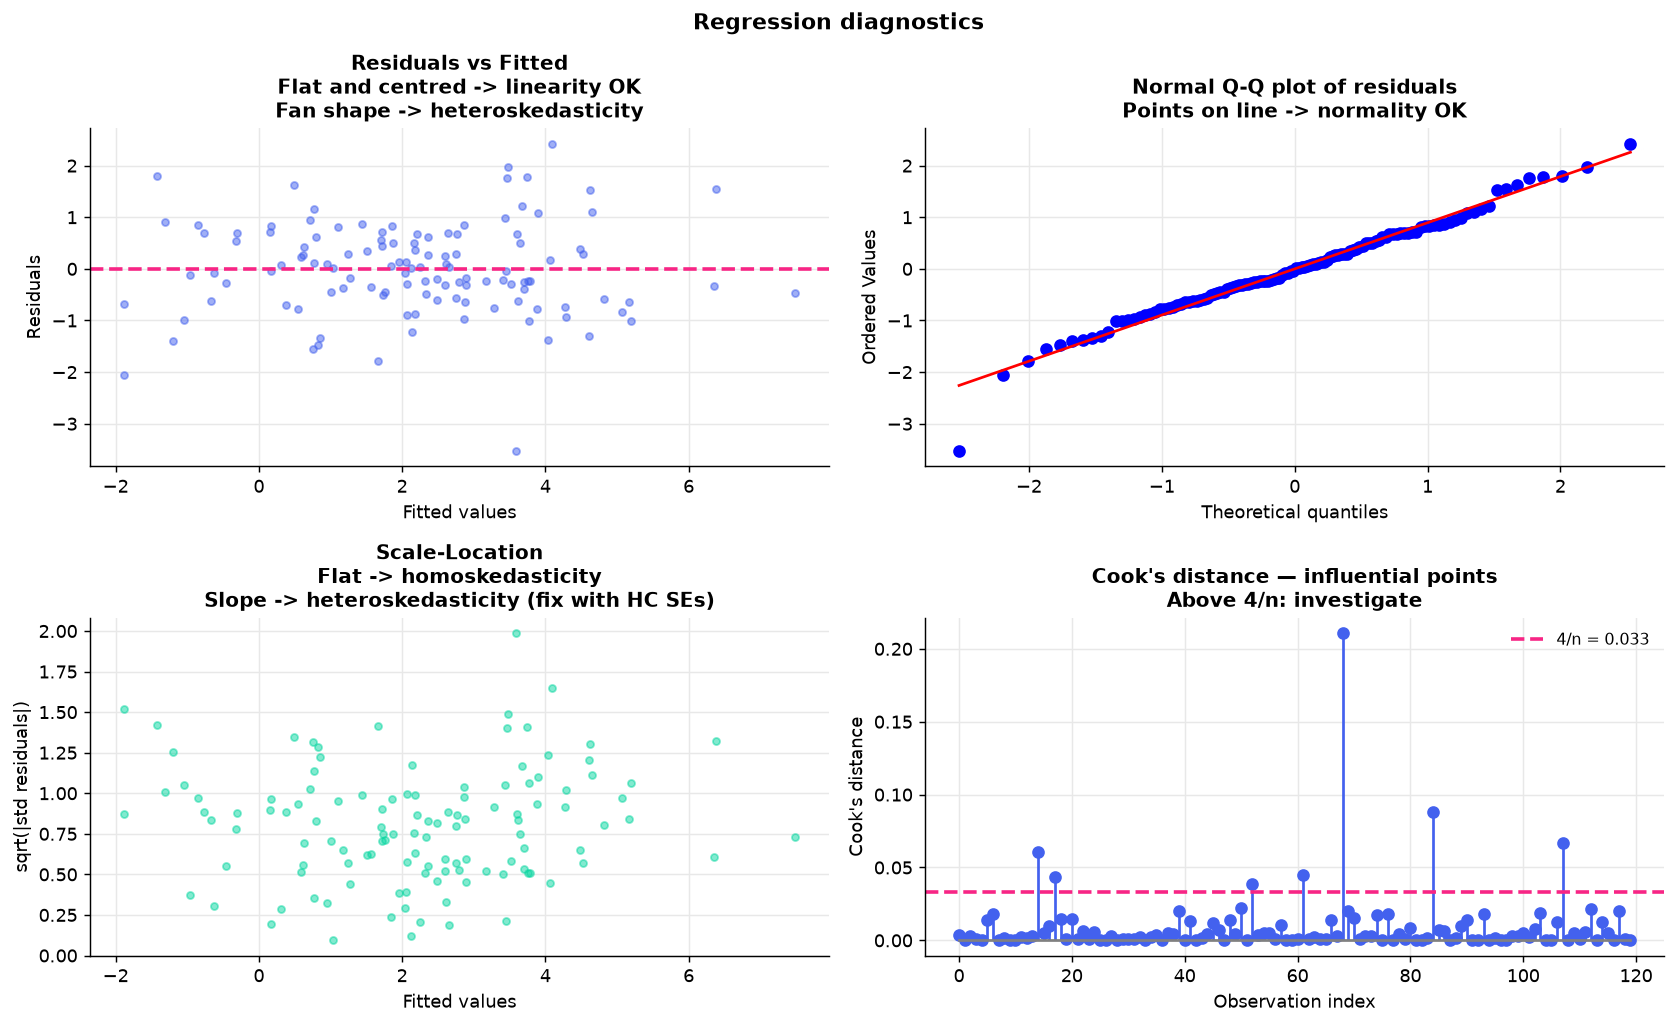

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0161      0.083     24.411      0.000       1.852       2.180
x1             1.6763      0.084     20.070      0.000       1.511       1.842
x2            -0.7051      0.086     -8.183      0.000      -0.876      -0.534


In [3]:
# ── Regression diagnostics ───────────────────────────────────────────────
np.random.seed(5)
n_r = 120
x1 = np.random.normal(0, 1, n_r)
x2 = np.random.normal(0, 1, n_r)
# True model: nonlinear + heteroskedastic noise
y_r = 2 + 1.5*x1 - 0.8*x2 + np.random.normal(0, 0.5 + 0.5*np.abs(x1), n_r)

X_r = sm.add_constant(pd.DataFrame({'x1': x1, 'x2': x2}))
mod = sm.OLS(y_r, X_r).fit()

fitted = mod.fittedvalues
resid  = mod.resid
std_resid = resid / resid.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted, resid, s=15, alpha=0.5, color='#4361ee')
axes[0,0].axhline(0, color='#f72585', lw=2, linestyle='--')
axes[0,0].set_xlabel('Fitted values'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted\nFlat and centred -> linearity OK\nFan shape -> heteroskedasticity')

# 2. Q-Q plot
stats.probplot(resid, plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q plot of residuals\nPoints on line -> normality OK')

# 3. Scale-Location (sqrt |standardised residuals| vs fitted)
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)), s=15, alpha=0.5, color='#06d6a0')
axes[1,0].set_xlabel('Fitted values'); axes[1,0].set_ylabel('sqrt(|std residuals|)')
axes[1,0].set_title('Scale-Location\nFlat -> homoskedasticity\nSlope -> heteroskedasticity (fix with HC SEs)')

# 4. Cook's distance
influence = mod.get_influence()
cooks = influence.cooks_distance[0]
axes[1,1].stem(range(n_r), cooks, markerfmt='o', linefmt='#4361ee', basefmt='gray')
axes[1,1].axhline(4/n_r, color='#f72585', lw=2, linestyle='--', label=f'4/n = {4/n_r:.3f}')
axes[1,1].set_xlabel('Observation index'); axes[1,1].set_ylabel("Cook's distance")
axes[1,1].set_title("Cook's distance — influential points\nAbove 4/n: investigate")
axes[1,1].legend(fontsize=9)

plt.suptitle('Regression diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(mod.summary().tables[1])

## Regularization: Ridge and Lasso

When $p$ is large relative to $n$, OLS overfits. Regularization adds a penalty:

**Ridge (L2):** $\hat{\beta}_{ridge} = \arg\min \|y - X\beta\|^2 + \lambda\|\beta\|^2$
- Shrinks all coefficients toward zero; never sets them exactly to zero
- Handles multicollinearity well

**Lasso (L1):** $\hat{\beta}_{lasso} = \arg\min \|y - X\beta\|^2 + \lambda\|\beta\|_1$
- Can set coefficients exactly to zero → variable selection
- Unstable when predictors are correlated

**Elastic Net:** $\lambda_1\|\beta\|_1 + \lambda_2\|\beta\|^2$ — combines both

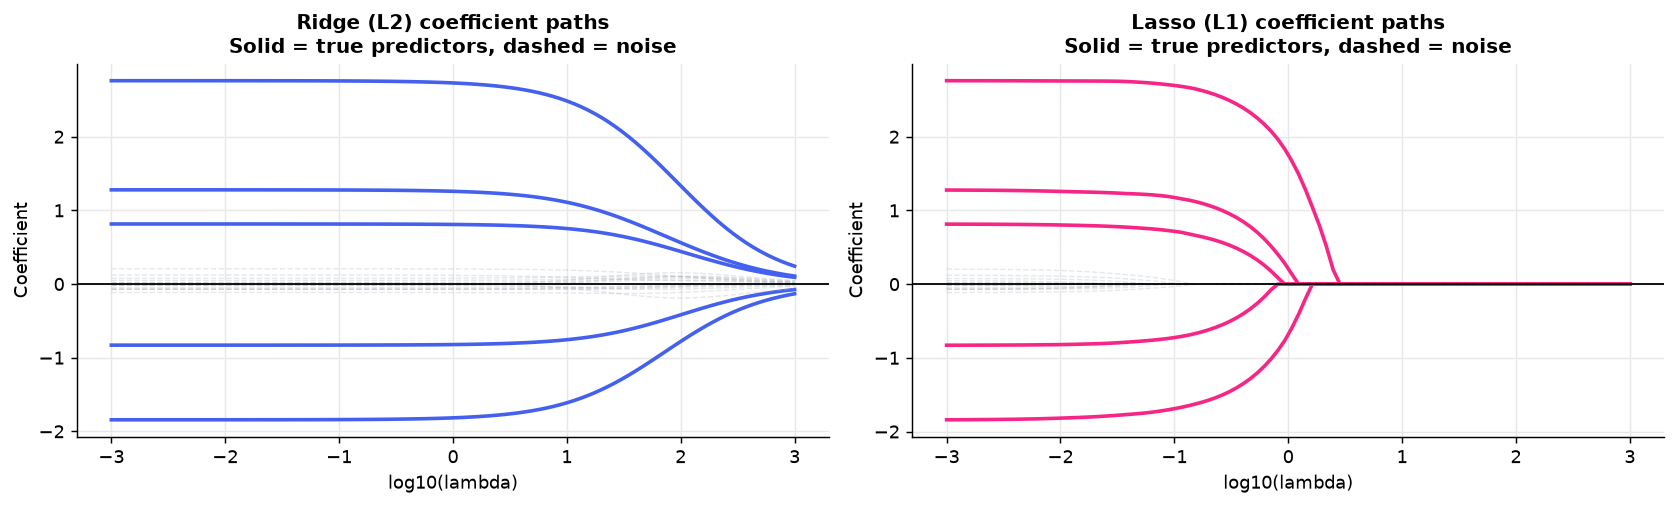

In [4]:
# ── Ridge vs Lasso: coefficient paths ────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

np.random.seed(10)
n_reg, p_reg = 100, 20
X_reg = np.random.normal(0, 1, (n_reg, p_reg))
# Only 5 true predictors
beta_true = np.zeros(p_reg)
beta_true[:5] = [3, -2, 1.5, -1, 0.8]
y_reg = X_reg @ beta_true + np.random.normal(0, 1, n_reg)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_reg)

alphas = np.logspace(-3, 3, 100)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_sc, y_reg).coef_ for a in alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=5000).fit(X_sc, y_reg).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, coefs, name, c in [(axes[0], ridge_coefs, 'Ridge (L2)', '#4361ee'),
                             (axes[1], lasso_coefs, 'Lasso (L1)', '#f72585')]:
    for j in range(p_reg):
        ls = '-' if j < 5 else '--'
        lw = 2 if j < 5 else 0.8
        alpha = 1.0 if j < 5 else 0.3
        ax.plot(np.log10(alphas), coefs[:, j], ls=ls, lw=lw, alpha=alpha,
                color=c if j<5 else '#adb5bd')
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('log10(lambda)'); ax.set_ylabel('Coefficient')
    ax.set_title(f'{name} coefficient paths\nSolid = true predictors, dashed = noise')

plt.tight_layout()
plt.show()